In [1]:
# First need to add src to path
import sys
import os
import yaml
from pathlib import Path




# project_root = Path("..")  # example
project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [2]:
from src.data.datasets import SegmentationDataset
from src.data.transforms import get_baseline_train_transforms, get_baseline_val_transforms, get_baseline_test_transforms
from src.data.loader import get_datasets, get_dataloaders

from src.models.model_factory import build_model

from src.training.train import train_one_epoch, evaluate

from src.metrics.segmentation import *



/Users/giladfelsen/my_dl_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
config_path = "/Users/giladfelsen/my_dl_project/configs/basic.yaml"
with open(config_path) as f:
    cfg = yaml.safe_load(f)

In [4]:
cfg["batch_size"] = 64

In [5]:
import torch
from torch import optim

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

train_trans = get_baseline_train_transforms()
val_trans = get_baseline_val_transforms()
test_trans = get_baseline_test_transforms()

train_dataset, val_dataset, test_dataset = get_datasets(cfg, train_trans, val_trans, test_trans)
train_loader, val_loader, test_loader = get_dataloaders(config_path, train_trans, val_trans, test_trans, cfg=cfg)

model = build_model(**cfg["model"]).to(device)

opt_cfg = cfg.get("optimizer", {})
lr = opt_cfg.get("lr", 1e-3)
wd = opt_cfg.get("weight_decay", 0.0)

# optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

In [6]:
print(f"Using device: {device}")

Using device: mps


In [7]:
gamma = 1.05
init_lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=init_lr, weight_decay=wd)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)

# 1e-4 * 1.05**180


In [8]:
print(f"Number of batches per epoch: {len(train_loader)}")
cfg["batch_size"]

Number of batches per epoch: 23


64

In [22]:
epochs = 8
gamma = 1.04
init_lr = 1e-3
final_lr = init_lr * gamma**(epochs * len(train_loader))
print(f"Final LR after one epoch will be: {final_lr}")
# 0.008900522746666228

Final LR after one epoch will be: 1.3618661675949755


In [23]:

# epochs = 2
# gamma = 1.025
# init_lr = 1e-4
# final_lr = init_lr * gamma**(epochs * len(train_loader))
print(f"Final LR after one epoch will be: {final_lr}") # = 0.84126

model = build_model(**cfg["model"]).to(device)

optimizer = optim.Adam(model.parameters(), lr=init_lr, weight_decay=wd)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)


lossi = []
lrs = []
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        lrs.append(scheduler.get_last_lr()[0]) # log lr before step
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = torch.nn.functional.cross_entropy(output, target, ignore_index=255)
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())
        
        scheduler.step()
        if batch_idx % 10==0:
            print(f"Batch: {batch_idx + len(train_loader)*epoch}, Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.4f}")
            if scheduler.get_last_lr()[0] > 1:
                break

    if scheduler.get_last_lr()[0] > 1:
        break
        

Final LR after one epoch will be: 1.3618661675949755
Batch: 0, Loss: 3.3946, LR: 0.0010
Batch: 10, Loss: 2.1043, LR: 0.0015
Batch: 20, Loss: 1.6055, LR: 0.0023
Batch: 23, Loss: 1.6302, LR: 0.0026
Batch: 33, Loss: 1.1970, LR: 0.0038
Batch: 43, Loss: 1.2221, LR: 0.0056
Batch: 46, Loss: 1.0672, LR: 0.0063
Batch: 56, Loss: 1.1316, LR: 0.0094
Batch: 66, Loss: 1.0018, LR: 0.0138
Batch: 69, Loss: 1.0064, LR: 0.0156
Batch: 79, Loss: 0.9616, LR: 0.0230
Batch: 89, Loss: 1.1826, LR: 0.0341
Batch: 92, Loss: 1.1321, LR: 0.0384
Batch: 102, Loss: 1.5448, LR: 0.0568
Batch: 112, Loss: 1.2577, LR: 0.0841
Batch: 115, Loss: 1.2139, LR: 0.0946
Batch: 125, Loss: 1.1832, LR: 0.1400
Batch: 135, Loss: 1.2160, LR: 0.2073
Batch: 138, Loss: 1.2267, LR: 0.2331
Batch: 148, Loss: 1.1622, LR: 0.3451
Batch: 158, Loss: 1.2300, LR: 0.5109
Batch: 161, Loss: 1.2083, LR: 0.5746
Batch: 171, Loss: 1.1051, LR: 0.8506
Batch: 181, Loss: 1.2004, LR: 1.2591


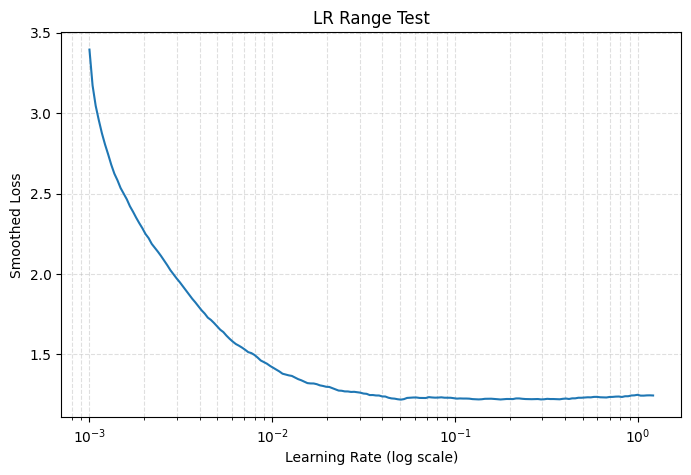

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Exponential Moving Average smoothing ---
beta = 0.98
avg_loss = 0.0
smoothed_losses = []
t = 0

for loss in lossi:
    t += 1
    avg_loss = beta * avg_loss + (1 - beta) * loss
    smoothed = avg_loss / (1 - beta ** t)  # bias-correction
    smoothed_losses.append(smoothed)

# Convert to numpy arrays
lrs_arr = np.array(lrs)
smooth_arr = np.array(smoothed_losses)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(lrs_arr, smooth_arr)
plt.xscale('log')
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Smoothed Loss")
plt.title("LR Range Test")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()


In [ ]:
lr_list = [0.0003, 0.001, 0.0025, 0.01, 0.02]

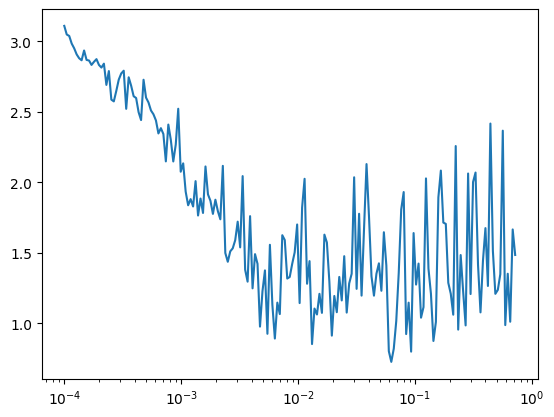

In [ ]:
import matplotlib.pyplot as plt

plt.plot(lrs, lossi)
plt.xscale('log')

plt.show()

In [44]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
import time

def train_one_epoch_lr_sweep(
    lr_list,
    train_loader,
    build_model,
    cfg,
    device,
    wd=0.0,
    beta=0.98,
    epochs=1
):
    """
    For each LR:
      - trains a fresh randomly initialized model for `epochs`
      - records raw batch losses
      - computes EMA-smoothed losses from raw losses

    Returns:
      all_raw_losses      -> list of lists (per LR)
      all_smoothed_losses -> list of lists (per LR)
    """

    t0 = time.time()

    all_raw_losses = []
    all_smoothed_losses = []

    for lr in lr_list:

        # --- Reproducibility ---
        seed = 42
        torch.manual_seed(seed)
        random.seed(seed)
        np.random.seed(seed)

        # --- Fresh model for each LR ---
        mt0 = time.time()
        model = build_model(**cfg["model"]).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        model.train()
        mt1 = time.time()

        raw_losses = []
        t1 = time.time()

        # ----------------------------
        # Training for `epochs`
        # ----------------------------
        for _ in range(epochs):
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)

                optimizer.zero_grad()
                output = model(data)

                loss = F.cross_entropy(output, target, ignore_index=255)
                loss.backward()
                optimizer.step()

                raw_losses.append(loss.item())

        t2 = time.time()
        training_time = t2 - t1
        model_init_time = mt1 - mt0
        final_loss = raw_losses[-1]
        print(
            f"LR={lr:.5f}, epochs={epochs} , final loss={final_loss:.4f} "
            f"Train time: {training_time:.1f} sec, Model init time: {model_init_time:.1f} sec"
            f", total elapsed: {(t2 - t0)/60:.1f} Minutes"
            
        )

        all_raw_losses.append(raw_losses)

        # ----------------------------
        # Compute EMA smoothing (from raw losses)
        # ----------------------------
        avg = 0.0
        smoothed = []
        t = 0

        for x in raw_losses:
            t += 1
            avg = beta * avg + (1 - beta) * x
            bias_corrected = avg / (1 - beta**t)
            smoothed.append(bias_corrected)

        all_smoothed_losses.append(smoothed)

    # -----------------------
    # Plot the learning curves (smoothed)
    # -----------------------
    t3 = time.time()
    print(f"Plotting learning curves, total time elapsed: {t3 - t0:.1f} sec")

    plt.figure(figsize=(9, 6))

    for lr, smoothed in zip(lr_list, all_smoothed_losses):
        plt.plot(smoothed, label=f"lr={lr}")

    plt.xlabel("Batch index")
    plt.ylabel("Smoothed Loss")
    plt.title("Learning Curves for Different Learning Rates (Smoothed)")
    plt.legend()
    plt.grid(True, ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return all_raw_losses, all_smoothed_losses


LR=0.00030, epochs=5 , final loss=0.9621 Train time: 303.6 sec, Model init time: 0.4 sec, total elapsed: 5.1 Minutes
LR=0.00100, epochs=5 , final loss=0.9419 Train time: 308.3 sec, Model init time: 0.1 sec, total elapsed: 10.2 Minutes
LR=0.00250, epochs=5 , final loss=0.9375 Train time: 310.2 sec, Model init time: 0.1 sec, total elapsed: 15.4 Minutes
LR=0.01000, epochs=5 , final loss=0.9535 Train time: 314.7 sec, Model init time: 0.1 sec, total elapsed: 20.6 Minutes
LR=0.02000, epochs=5 , final loss=0.9577 Train time: 314.1 sec, Model init time: 0.3 sec, total elapsed: 25.9 Minutes
LR=0.03000, epochs=5 , final loss=0.9738 Train time: 317.9 sec, Model init time: 0.1 sec, total elapsed: 31.2 Minutes
Plotting learning curves, total time elapsed: 1869.9 sec


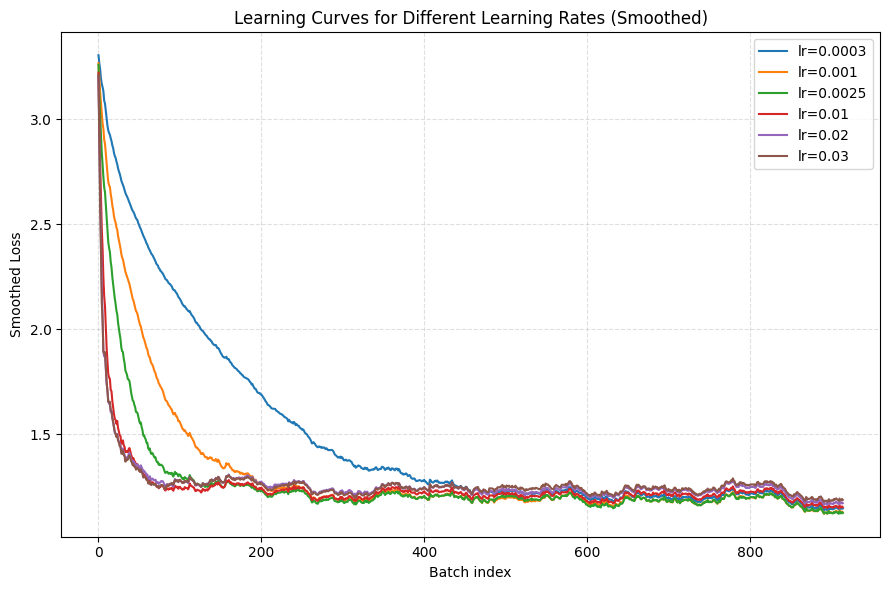

In [45]:
lr_list = [0.0003, 0.001, 0.0025, 0.01, 0.02, 0.03]
epochs = 5
expected_time_minutes = len(lr_list) * epochs  # approx seconds per epoch
all_raw_losses, all_smoothed_losses = train_one_epoch_lr_sweep(
    lr_list,
    train_loader=train_loader,
    build_model=build_model,
    cfg=cfg,
    device=device,
    wd=1e-4,
    epochs=epochs
)

LR=0.00100, epochs=2 Train time: 122.6 sec, Model init time: 0.4 sec
LR=0.10000, epochs=2 Train time: 122.4 sec, Model init time: 0.4 sec
Plotting learning curves, total time elapsed: 245.8 sec


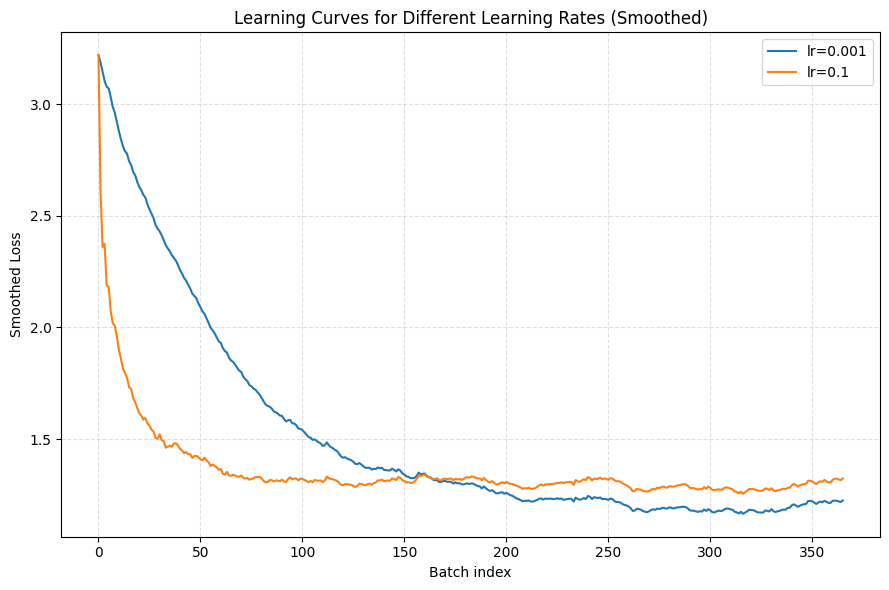

In [42]:
# lr_list = [0.0003, 0.001, 0.0025, 0.01, 0.02, 0.1]
# lr_list = [0.001, 0.1]
lr_list = [0.0003, 0.001, 0.0025, 0.01, 0.02, 0.1]
epochs = 5
expected_time_minutes = len(lr_list) * epochs  # approx seconds per epoch
all_raw_losses, all_smoothed_losses = train_one_epoch_lr_sweep(
    lr_list,
    train_loader=train_loader,
    build_model=build_model,
    cfg=cfg,
    device=device,
    wd=1e-4,
    epochs=epochs
)

LR=0.00030 done in 61.1 sec, total elapsed: 61.5 sec
LR=0.00100 done in 60.7 sec, total elapsed: 122.3 sec
LR=0.00250 done in 61.1 sec, total elapsed: 183.5 sec
LR=0.01000 done in 60.7 sec, total elapsed: 244.3 sec
LR=0.02000 done in 60.6 sec, total elapsed: 305.0 sec
Plotting learning curves, total time elapsed: 305.0 sec


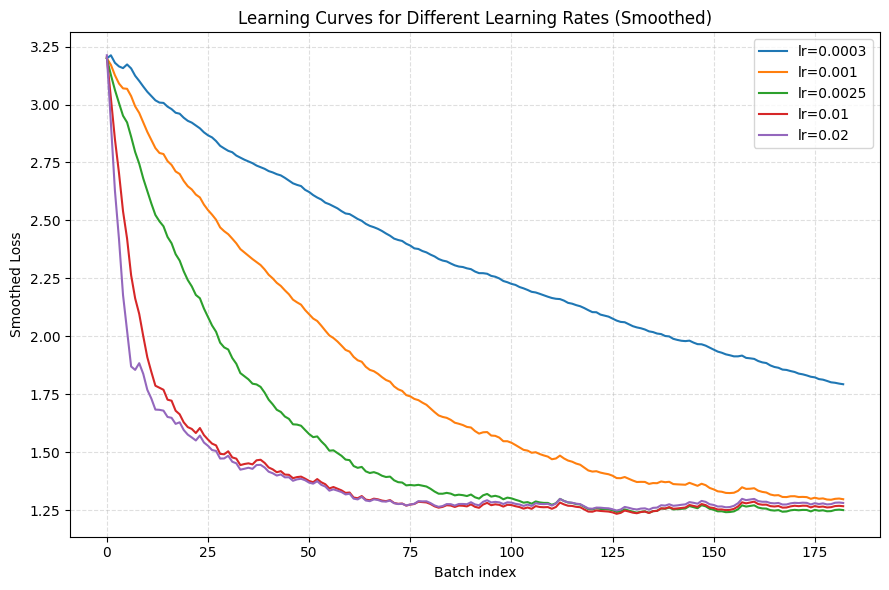

In [38]:
lr_list = [0.0003, 0.001, 0.0025, 0.01, 0.02, 0.1]
all_raw_losses, all_smoothed_losses = train_one_epoch_lr_sweep(
    lr_list,
    train_loader=train_loader,
    build_model=build_model,
    cfg=cfg,
    device=device,
    wd=1e-4
)

In [36]:
# device

device(type='mps')